In [34]:
import networkx as nx
import matplotlib.pyplot as plt

arquivo = "testes/entrada.txt"

In [35]:
def ler_casos(arquivo):
    with open(arquivo, encoding="utf-8") as arquivo_entrada:
        linhas = [linha.split() for linha in arquivo_entrada if linha.strip()]

    casos = []
    indice = 0

    while indice < len(linhas):
        numero_ilhas, numero_pontes, numero_sedes = map(int, linhas[indice])
        indice += 1

        pontes = []
        for _ in range(numero_pontes):
            origem, destino, peso = map(int, linhas[indice])
            pontes.append((origem, destino, peso))
            indice += 1

        sedes = []
        for _ in range(numero_sedes):
            sede, deposito = map(int, linhas[indice])
            sedes.append((sede, deposito))
            indice += 1

        casos.append({
            "numero_ilhas": numero_ilhas,
            "pontes": pontes,
            "sedes": sedes,
        })

    return casos

In [36]:
def criar_grafo(caso):
    grafo = nx.Graph()
    grafo.add_nodes_from(range(1, caso["numero_ilhas"] + 1))
    grafo.add_weighted_edges_from(caso["pontes"], weight="weight")
    return grafo

In [37]:
def resolver_caso(caso):
    grafo = criar_grafo(caso)

    arvore_maxima = nx.maximum_spanning_tree(
        grafo,
        weight="weight",
        algorithm="kruskal",
    )

    return grafo, arvore_maxima

In [38]:
def responder_consulta(arvore_maxima, inicio, fim):
    caminho = nx.shortest_path(arvore_maxima, inicio, fim)

    pesos_do_caminho = [
        arvore_maxima[origem][destino]["weight"]
        for origem, destino in zip(caminho, caminho[1:])
    ]

    peso_maximo = min(pesos_do_caminho)

    return caminho, peso_maximo

def imprimir_consultas(arvore_maxima, sedes):
    for inicio, fim in sedes:
        caminho, peso_maximo = responder_consulta(arvore_maxima, inicio, fim)

        print(f"{inicio} → {fim}")
        print(f"Caminho: {caminho}")
        print(f"Peso máximo: {peso_maximo}\n")

In [39]:
def plotar_grafo_inicial(grafo, posicoes, titulo):
    plt.figure(figsize=(8, 6))
    nx.draw_networkx(
        grafo,
        posicoes,
        with_labels=True,
        node_color="lightblue",
        node_size=900,
        edge_color="gray",
        width=2,
        font_weight="bold",
    )

    pesos = nx.get_edge_attributes(grafo, "weight")
    nx.draw_networkx_edge_labels(grafo, posicoes, edge_labels=pesos)

    plt.title(titulo)
    plt.axis("off")
    plt.show()

In [40]:
def plotar_pontes_de_interesse(grafo, arvore_maxima, posicoes, titulo):
    pontes_interesse = list(arvore_maxima.edges())

    pontes_descartadas = [
        (origem, destino)
        for origem, destino in grafo.edges()
        if not arvore_maxima.has_edge(origem, destino)
    ]

    pesos = nx.get_edge_attributes(grafo, "weight")

    plt.figure(figsize=(8, 6))

    nx.draw_networkx_nodes(
        grafo,
        posicoes,
        node_color="lightblue",
        node_size=900,
    )
    nx.draw_networkx_labels(grafo, posicoes, font_weight="bold")

    nx.draw_networkx_edges(
        grafo,
        posicoes,
        edgelist=pontes_descartadas,
        edge_color="lightgray",
        width=2,
        style="dashed",
        label="Pontes descartadas",
    )

    nx.draw_networkx_edges(
        grafo,
        posicoes,
        edgelist=pontes_interesse,
        edge_color="red",
        width=3.5,
        label="Pontes de interesse",
    )

    nx.draw_networkx_edge_labels(grafo, posicoes, edge_labels=pesos)

    plt.title(titulo)
    plt.legend(loc="best")
    plt.axis("off")
    plt.show()

    print("Pontes de interesse:", list(arvore_maxima.edges(data="weight")))
    print("Pontes descartadas:", [
        (origem, destino, grafo[origem][destino]["weight"])
        for origem, destino in pontes_descartadas
    ])

Casos no arquivo: 1 

===== Caso 1 =====
Ilhas: [1, 2, 3, 4]
Pontes: [(1, 2, 9), (1, 3, 0), (2, 3, 8), (2, 4, 7), (3, 4, 4)]


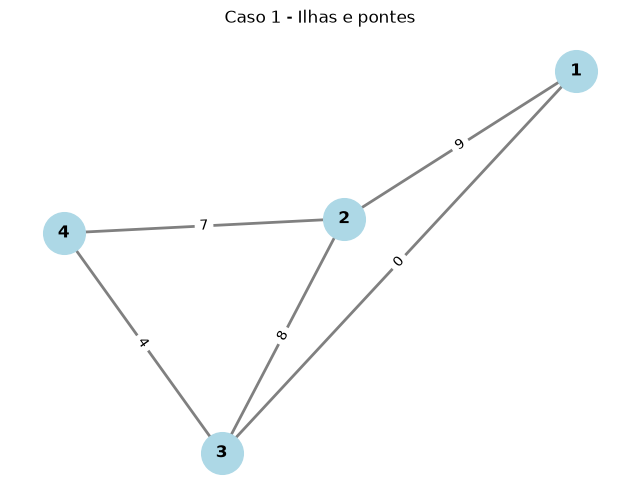

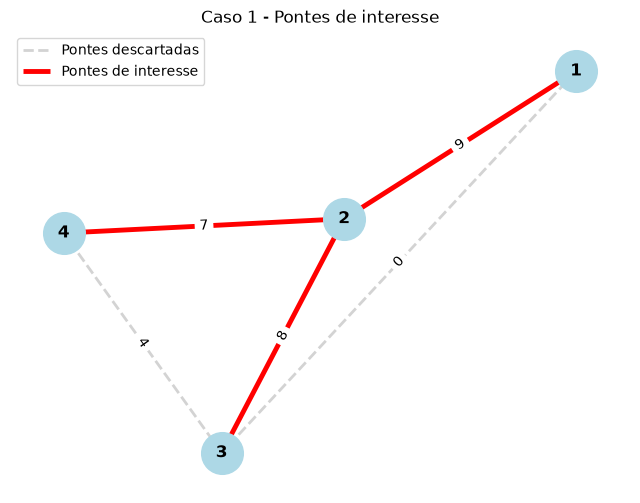

Pontes de interesse: [(1, 2, 9), (2, 3, 8), (2, 4, 7)]
Pontes descartadas: [(1, 3, 0), (3, 4, 4)]

1 → 4
Caminho: [1, 2, 4]
Peso máximo: 7

2 → 1
Caminho: [2, 1]
Peso máximo: 9

3 → 1
Caminho: [3, 2, 1]
Peso máximo: 8

4 → 3
Caminho: [4, 2, 3]
Peso máximo: 7



In [41]:
casos = ler_casos(arquivo)

print("Casos no arquivo:", len(casos), "\n")

for numero_caso, caso in enumerate(casos, 1):
    grafo, arvore_maxima = resolver_caso(caso)

    print(f"===== Caso {numero_caso} =====")
    print("Ilhas:", list(grafo.nodes))
    print("Pontes:", list(grafo.edges(data="weight")))
    posicoes = nx.spring_layout(grafo, seed=42)

    plotar_grafo_inicial(grafo, posicoes, f"Caso {numero_caso} - Ilhas e pontes")
    plotar_pontes_de_interesse(
        grafo,
        arvore_maxima,
        posicoes,
        f"Caso {numero_caso} - Pontes de interesse",
    )

    print()
    imprimir_consultas(arvore_maxima, caso["sedes"])